In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
from collections import Counter

In [3]:
df = pd.read_csv(r"C:\Users\HP-PC\Desktop\Python data analytics\black friday dataset\train.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [5]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [6]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [7]:
for col in ['Product_Category_2', 'Product_Category_3']:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\HP-PC\AppData\Local\Temp\ipykernel_7016\450261602.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
df.duplicated().sum()

0

In [9]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.260768,14.989567,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,4.294093,2.739846,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,8.000000,16.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8.000000,16.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,14.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [10]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

User_ID: 5891
Product_ID: 3631
Gender: 2
Age: 7
Occupation: 21
City_Category: 3
Stay_In_Current_City_Years: 5
Marital_Status: 2
Product_Category_1: 20
Product_Category_2: 17
Product_Category_3: 15
Purchase: 18105


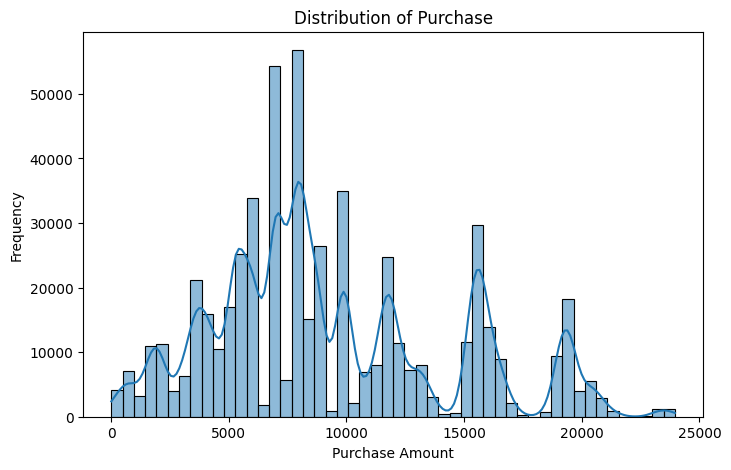

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase'], bins=50, kde=True)
plt.title("Distribution of Purchase")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

<Axes: >

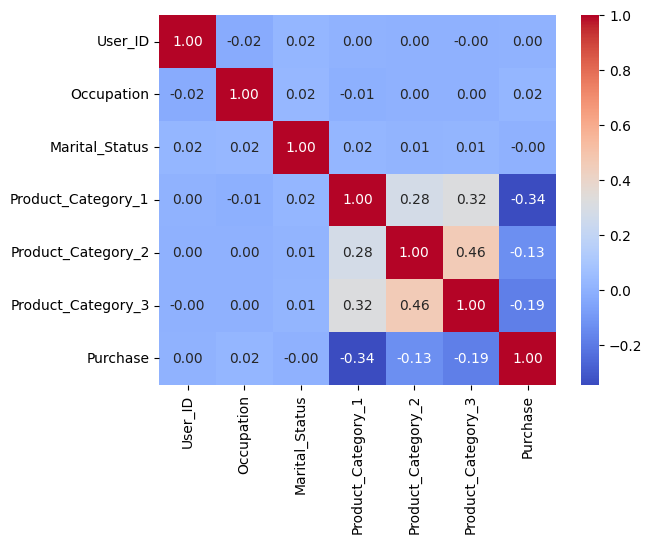

In [14]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm", fmt=".2f")


In [17]:
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
df['Age'] = df['Age'].map({'0-17': 1, '18-25': 2, '26-35': 3, '36-45': 4, '46-50': 5, '51-55': 6, '55+': 7})

In [18]:
df['City_Category'] = df['City_Category'].map({'A': 1, 'B': 2, 'C': 3})
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '').astype(int)

In [19]:
df['Total_Product_Categories'] = df[['Product_Category_1', 'Product_Category_2', 'Product_Category_3']].nunique(axis=1)
df['Purchase_Per_Product'] = df.groupby('Product_ID')['Purchase'].transform('mean')
df['Purchase_Per_User'] = df.groupby('User_ID')['Purchase'].transform('mean')

In [20]:
df['User_Purchase_Count'] = df.groupby('User_ID')['Purchase'].transform('count')
df['User_Age_Category'] = df['User_ID'].astype(str) + "_" + df['Age'].astype(str)

In [21]:
print("\nSkewness & Kurtosis:")
for col in ['Purchase', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']:
    print(f"{col} - Skewness: {skew(df[col])}, Kurtosis: {kurtosis(df[col])}")


Skewness & Kurtosis:
Purchase - Skewness: 0.6001383671643447, Kurtosis: -0.3383853975360749
Product_Category_1 - Skewness: 1.0257321367385983, Kurtosis: 1.2347348403217397
Product_Category_2 - Skewness: 0.1987251583572936, Kurtosis: -0.8797101379923586
Product_Category_3 - Skewness: -2.6894457363415842, Kurtosis: 6.23235450120637


In [22]:
scaler = StandardScaler()
df[['Purchase', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']] = scaler.fit_transform(df[['Purchase', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']])

In [23]:
df['Purchase_Scaled'] = MinMaxScaler().fit_transform(df[['Purchase']])

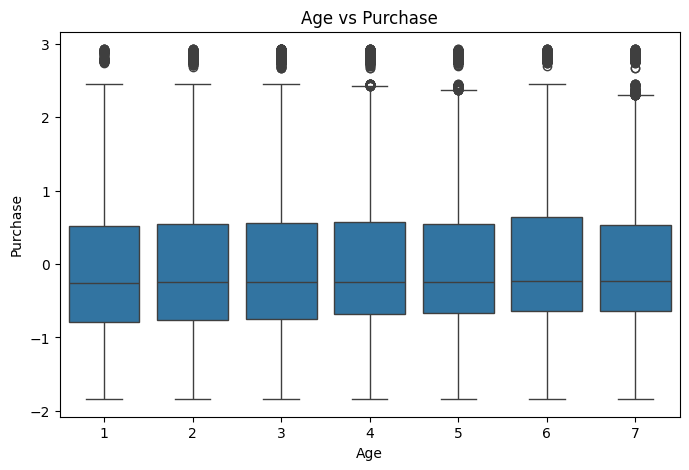

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Age', y='Purchase', data=df)
plt.title("Age vs Purchase")
plt.show()

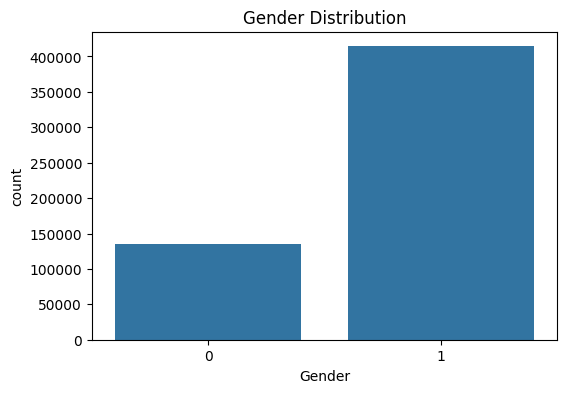

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

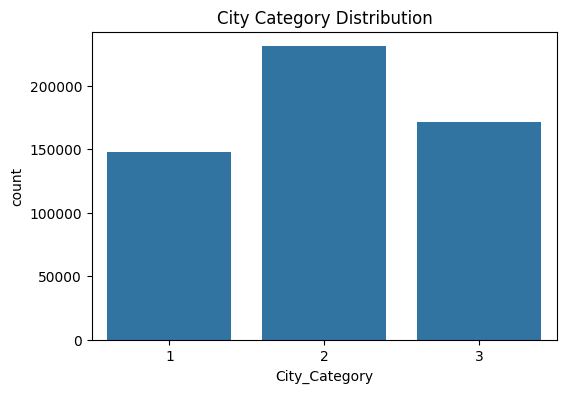

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='City_Category', data=df)
plt.title("City Category Distribution")
plt.show()

In [27]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df.set_index('Timestamp')['Purchase'].resample('M').sum().plot()
    plt.title("Monthly Purchase Trends")
    plt.ylabel("Total Purchase")
    plt.show()

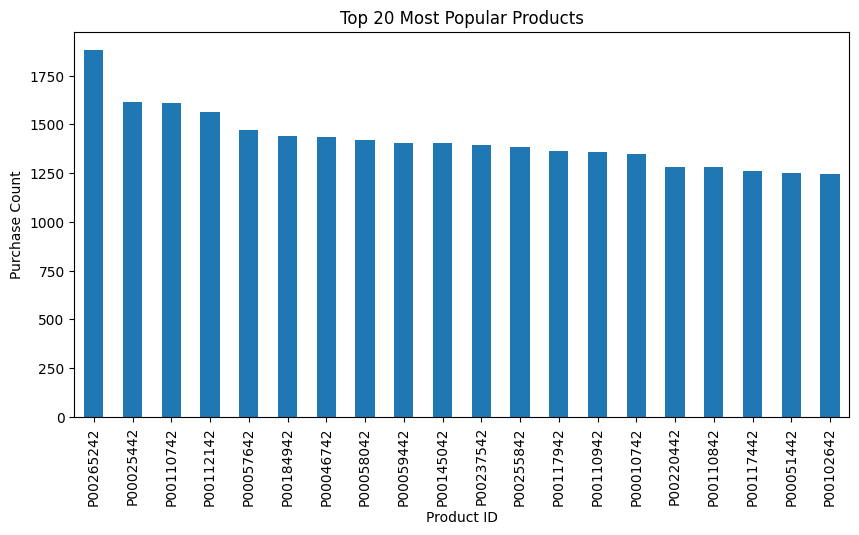

In [28]:
plt.figure(figsize=(10,5))
df['Product_ID'].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Most Popular Products")
plt.xlabel("Product ID")
plt.ylabel("Purchase Count")
plt.show()

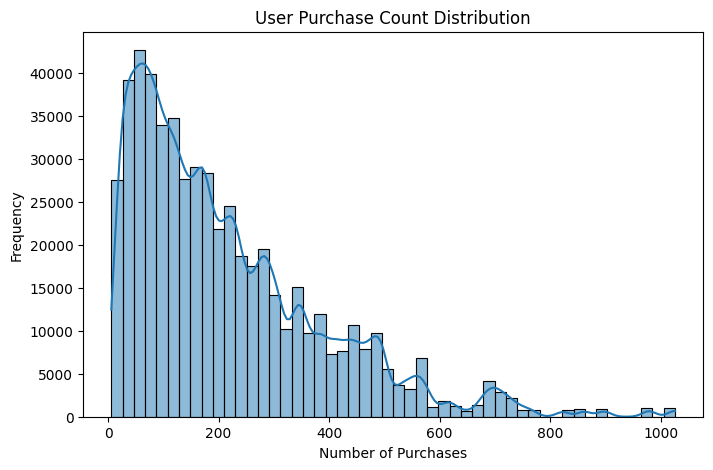

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['User_Purchase_Count'], bins=50, kde=True)
plt.title("User Purchase Count Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Frequency")
plt.show()

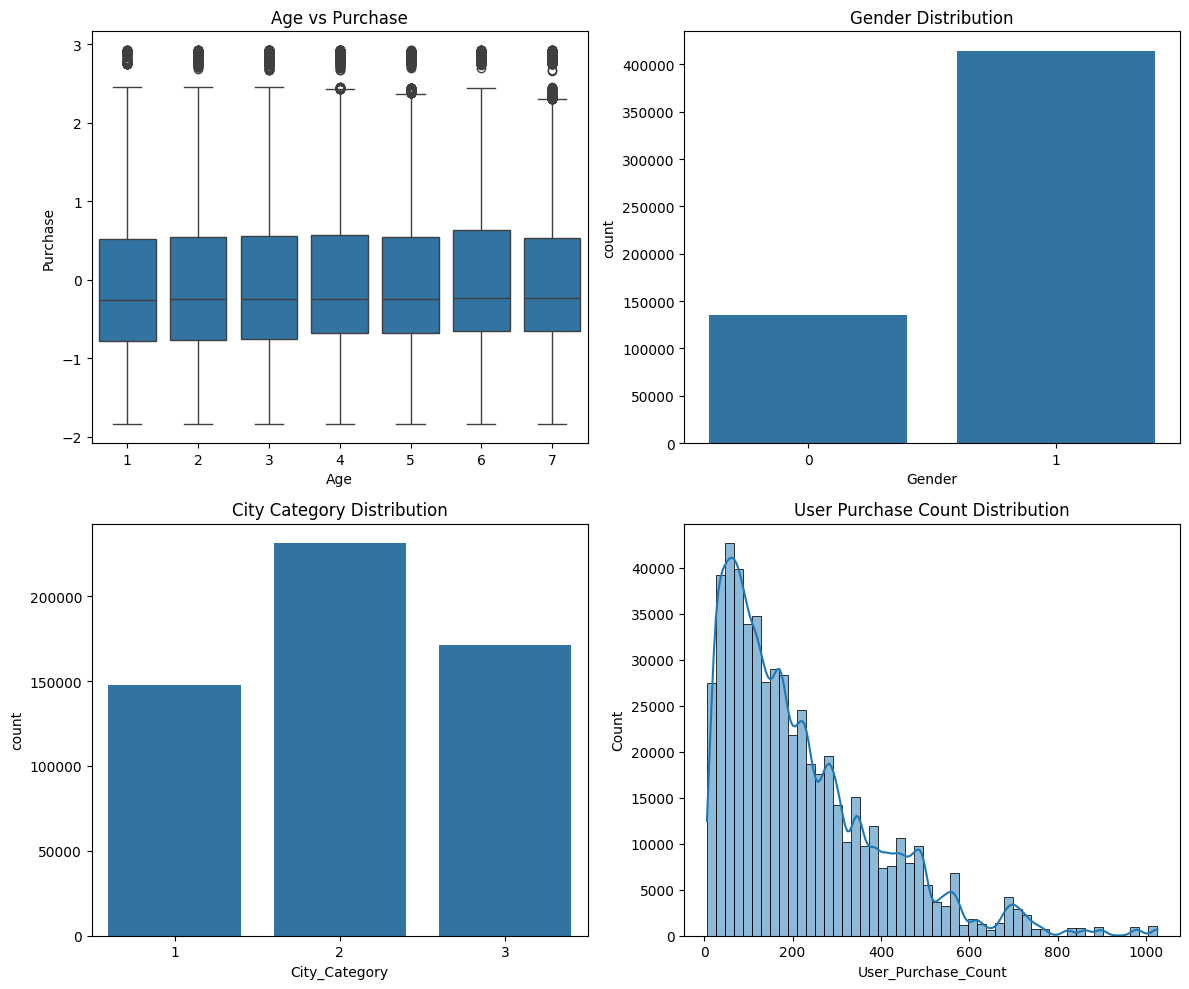

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(x='Age', y='Purchase', data=df, ax=axes[0, 0])
axes[0, 0].set_title("Age vs Purchase")

sns.countplot(x='Gender', data=df, ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution")

sns.countplot(x='City_Category', data=df, ax=axes[1, 0])
axes[1, 0].set_title("City Category Distribution")

sns.histplot(df['User_Purchase_Count'], bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("User Purchase Count Distribution")

plt.tight_layout()
plt.show()

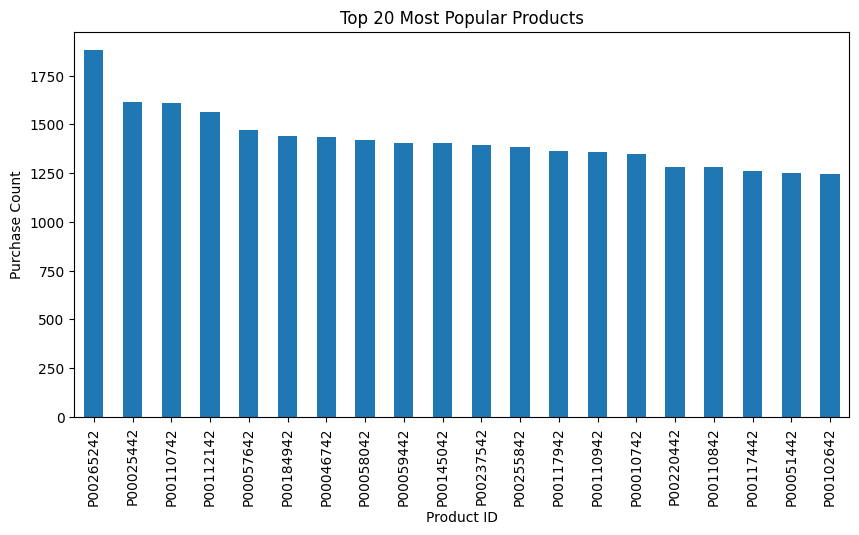

In [34]:
plt.figure(figsize=(10,5))
df['Product_ID'].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Most Popular Products")
plt.xlabel("Product ID")
plt.ylabel("Purchase Count")
plt.show()

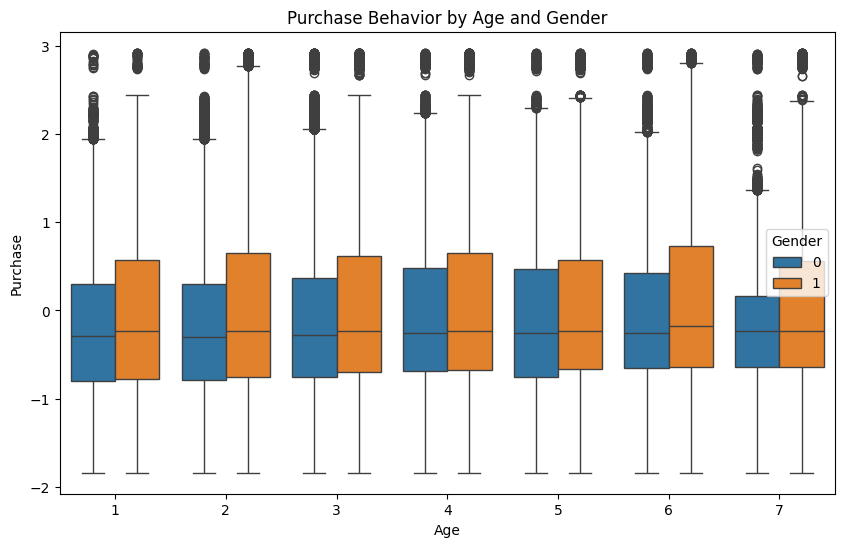

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age', y='Purchase', hue='Gender', data=df)
plt.title("Purchase Behavior by Age and Gender")
plt.show()

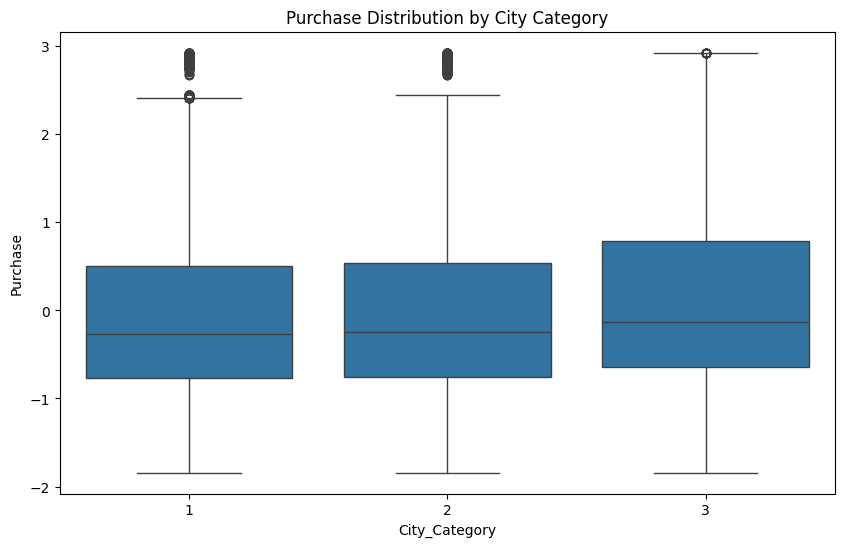

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='City_Category', y='Purchase', data=df)
plt.title("Purchase Distribution by City Category")
plt.show()

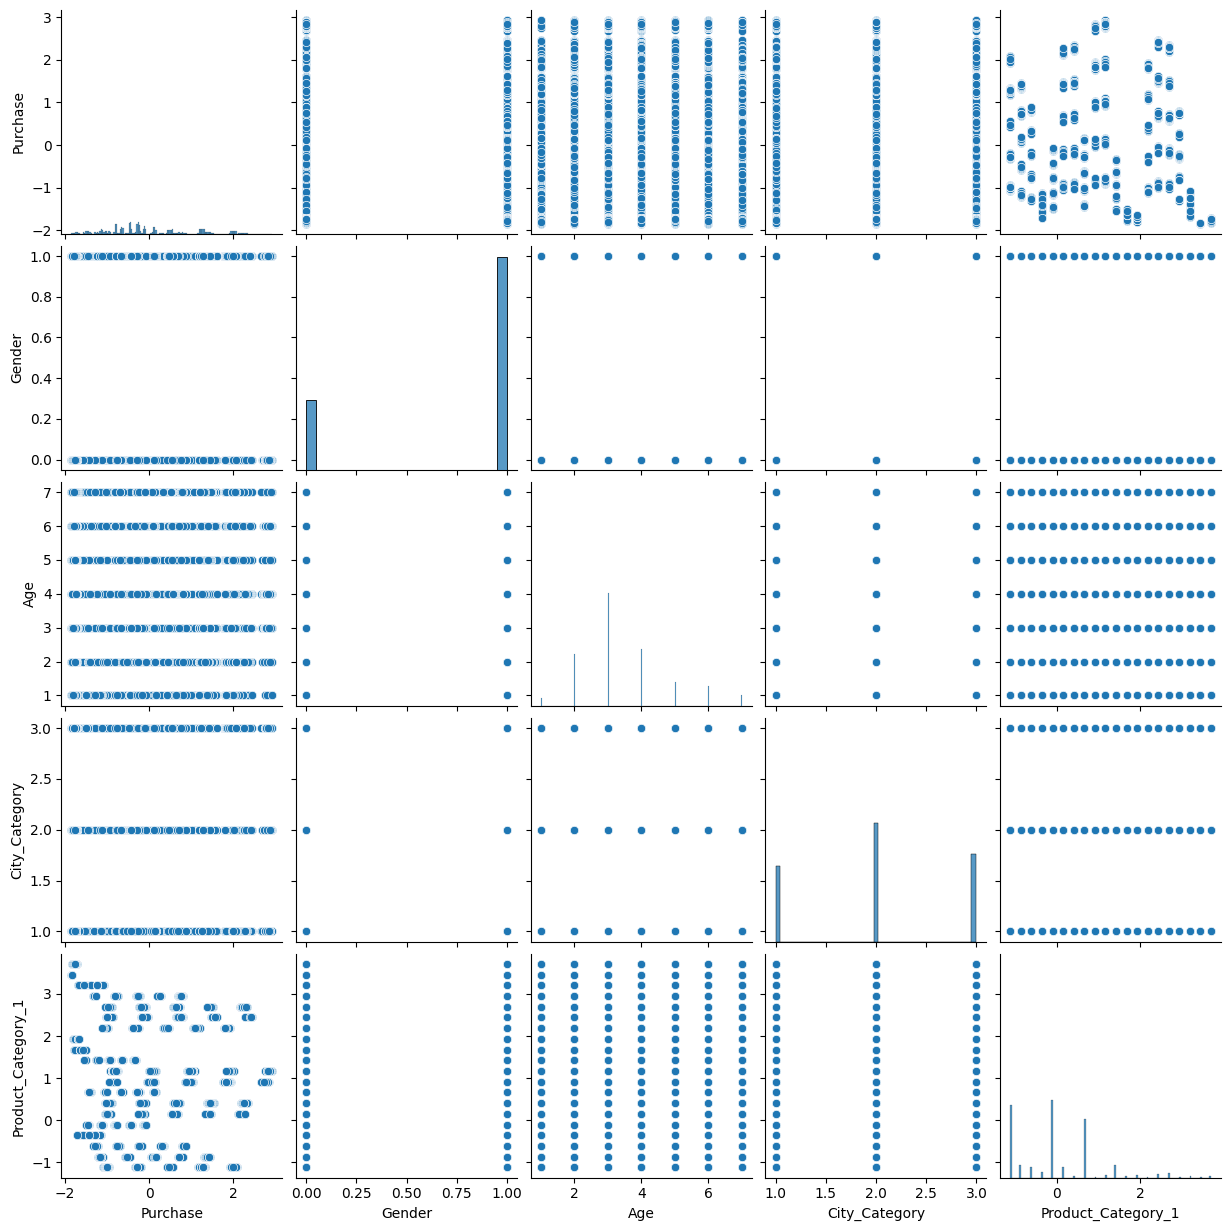

In [37]:
sns.pairplot(df[['Purchase', 'Gender', 'Age', 'City_Category', 'Product_Category_1']])
plt.show()